# Test with deeper models

We train recurrent models (vanilla **RNN** and **LSTM**) on the windows prepared in `data-preparation.ipynb`:

- Input: last 168 hours (7 days) x 6 scaled features
- Output: the 24 hourly returns of the next day

Every model is compared against naive baselines, because hourly returns are very noisy and a model has to beat "predict zero" to be useful.

In [1]:
import os
# conda's MKL numpy and pip's torch each ship libiomp5md.dll; without this the kernel dies on numpy.linalg calls
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

Device: cuda NVIDIA GeForce RTX 5060 Laptop GPU


### Load the data

We hold out the last 10% of the training samples (in time order) as a validation set for early stopping. Consecutive windows overlap by up to 191 hours, so we leave a gap of 191 samples between train and validation to keep validation targets out of the training inputs.

In [2]:
data = np.load('data/btc_hourly_windows.npz')
X_train_full, X_test = data['X_train'], data['X_test']
y_train_full, y_test = data['y_train'], data['y_test']
dates_train, dates_test = data['dates_train'], data['dates_test']
feature_cols = list(data['feature_cols'])

INPUT_HOURS, TARGET_HOURS = X_train_full.shape[1], y_train_full.shape[1]
GAP = INPUT_HOURS + TARGET_HOURS - 1

val_size = int(0.1 * len(X_train_full))
val_start = len(X_train_full) - val_size
X_train, y_train = X_train_full[:val_start - GAP], y_train_full[:val_start - GAP]
X_val, y_val = X_train_full[val_start:], y_train_full[val_start:]

print(f"Train: {X_train.shape}  ({dates_train[0]} -> {dates_train[val_start - GAP - 1]})")
print(f"Val:   {X_val.shape}  ({dates_train[val_start]} -> {dates_train[-1]})")
print(f"Test:  {X_test.shape}  ({dates_test[0]} -> {dates_test[-1]})")

Train: (92830, 168, 6)  (2012-01-09T00:00:00 -> 2022-08-11T21:00:00)
Val:   (10335, 168, 6)  (2022-08-19T21:00:00 -> 2023-10-24T11:00:00)
Test:  (25839, 168, 6)  (2023-10-24T12:00:00 -> 2026-10-05T02:00:00)


### Unscaled data

The `.npz` file only stores scaled inputs, so we recover the original values with the saved `StandardScaler` (`inverse_transform`), as described in `data-preparation.ipynb`. This lets us check how much the scaling matters for the recurrent models: raw prices go from a few dollars to over $100k, and volume reaches the tens of thousands.

In [3]:
import joblib

scaler = joblib.load('data/scaler.joblib')
n_features = len(feature_cols)

def unscale(X):
    return scaler.inverse_transform(X.reshape(-1, n_features)).reshape(X.shape).astype(np.float32)

X_train_raw, X_val_raw, X_test_raw = unscale(X_train), unscale(X_val), unscale(X_test)

DATA = {
    'scaled': (X_train, X_val, X_test),
    'unscaled': (X_train_raw, X_val_raw, X_test_raw),
}

pd.DataFrame({
    'train_min': X_train_raw.reshape(-1, n_features).min(0),
    'train_max': X_train_raw.reshape(-1, n_features).max(0),
    'test_min': X_test_raw.reshape(-1, n_features).min(0),
    'test_max': X_test_raw.reshape(-1, n_features).max(0),
}, index=feature_cols)

,train_min,train_max,test_min,test_max
Open,4.140625,68635.046875,27900.000000,126094.000000
High,4.169922,69000.000000,28190.000000,126272.000000
Low,3.799805,68447.000000,27742.000000,125333.000000
Close,4.140625,68627.015625,28013.001953,126111.000000
Volume,0.000000,20551.251953,0.000000,2477.217773
Return,-0.293396,0.348236,-0.049212,0.053018


### Feature check

The scaler was fitted on 2012-2023 data. The price columns (Open/High/Low/Close) of the test period sit far above anything seen during training, so for the model they are out-of-distribution inputs. We therefore compare two feature sets below: all features, and only the stationary ones (`Volume`, `Return`).

In [4]:
pd.DataFrame({
    'train_mean': X_train.reshape(-1, len(feature_cols)).mean(0),
    'train_max': X_train.reshape(-1, len(feature_cols)).max(0),
    'test_mean': X_test.reshape(-1, len(feature_cols)).mean(0),
    'test_max': X_test.reshape(-1, len(feature_cols)).max(0),
}, index=feature_cols).round(2)

,train_mean,train_max,test_mean,test_max
Open,-0.08,3.810000,4.42,7.60
High,-0.08,3.810000,4.42,7.57
Low,-0.08,3.820000,4.44,7.60
Close,-0.08,3.810000,4.42,7.60
Volume,0.05,33.520000,-0.44,3.53
Return,0.00,33.639999,-0.01,5.11


### Target scaling

Hourly returns have a std of about 0.01, which gives tiny loss values and gradients. We divide the targets by the training std for training, and multiply the predictions back before computing metrics. All reported metrics are in the original return units.

In [5]:
y_scale = float(y_train.std())
print(f"Target std (train): {y_scale:.5f}")

def to_tensor(a):
    return torch.from_numpy(np.ascontiguousarray(a, dtype=np.float32)).to(device)

def select(X, features):
    idx = [feature_cols.index(f) for f in features]
    return X[:, :, idx]

Target std (train): 0.01078


### Metrics and baselines

- **MSE / MAE** on the predicted hourly returns
- **Directional accuracy**: share of hours where the predicted sign matches the real one (hours with exactly 0 return are ignored)

Baselines:
- **Zero**: always predict 0% change
- **Train mean**: always predict the mean return of each target hour in the training set

In [6]:
def evaluate(y_true, y_pred):
    nonzero = y_true != 0
    return {
        'MSE': float(np.mean((y_true - y_pred) ** 2)),
        'MAE': float(np.mean(np.abs(y_true - y_pred))),
        'DirAcc': float(np.mean(np.sign(y_true[nonzero]) == np.sign(y_pred[nonzero]))),
    }

results = {}
results['Zero baseline'] = evaluate(y_test, np.zeros_like(y_test))
results['Zero baseline']['DirAcc'] = np.nan  # predicting 0 has no direction
results['Train-mean baseline'] = evaluate(y_test, np.broadcast_to(y_train.mean(0), y_test.shape))
pd.DataFrame(results).T

,MSE,MAE,DirAcc
Zero baseline,0.000025,0.003255,NaN
Train-mean baseline,0.000025,0.003256,0.506684


### Models

One class covers both architectures: a stacked recurrent layer (`nn.RNN` or `nn.LSTM`) reads the 168-hour sequence, and a linear head maps the last hidden state to the 24 hourly predictions.

In [7]:
class RecurrentForecaster(nn.Module):
    def __init__(self, cell, n_features, hidden_size=64, num_layers=2, dropout=0.2, horizon=TARGET_HOURS):
        super().__init__()
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM}[cell]
        self.rnn = rnn_cls(n_features, hidden_size, num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, horizon))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])

### Training loop

The whole dataset fits in GPU memory, so we skip the `DataLoader` and slice shuffled batches straight from GPU tensors. We use AdamW with gradient clipping (vanilla RNNs are prone to exploding gradients over 168 steps), stop early on validation loss, and restore the best weights.

The loss defaults to MSE; `loss_fn` lets us swap it (see the last section). Early stopping always uses the same loss as training.

In [8]:
@torch.no_grad()
def predict(model, X, batch_size=4096):
    model.eval()
    preds = [model(X[i:i + batch_size]) for i in range(0, len(X), batch_size)]
    return torch.cat(preds).cpu().numpy() * y_scale


def train_model(cell, features, data='scaled', loss_fn=None, hidden_size=64, num_layers=2, dropout=0.2, lr=1e-3,
                batch_size=512, max_epochs=30, patience=5, weight_decay=1e-4):
    torch.manual_seed(SEED)
    X_tr_src, X_va_src, _ = DATA[data]
    Xtr, Xva = to_tensor(select(X_tr_src, features)), to_tensor(select(X_va_src, features))
    ytr = to_tensor(y_train / y_scale)
    yva = torch.from_numpy(y_val / y_scale)

    model = RecurrentForecaster(cell, len(features), hidden_size, num_layers, dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = loss_fn or nn.MSELoss()

    history = {'train': [], 'val': []}
    best_val, best_state, bad_epochs = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xtr), device=device)
        total = 0.0
        for i in range(0, len(Xtr), batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[idx]), ytr[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item() * len(idx)
        train_loss = total / len(Xtr)

        # validation uses the same loss as training, on the scaled targets
        val_loss = loss_fn(torch.from_numpy(predict(model, Xva) / y_scale), yva).item()
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        print(f"[{cell}] epoch {epoch:2d}  train {train_loss:.4f}  val {val_loss:.4f}  ({time.time() - t0:.1f}s)")

        if val_loss < best_val:
            best_val, bad_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, history

### Experiments

Each experiment is a (cell, feature set, input scaling) combination. Only the inputs change between scaled and unscaled runs: the targets are always divided by `y_scale` during training. Losses are on the scaled targets, so a loss close to the target variance means the model is no better than a constant prediction.

In [9]:
ALL_FEATURES = feature_cols
STATIONARY_FEATURES = ['Volume', 'Return']

experiments = {}
for data_name in ['scaled', 'unscaled']:
    for cell in ['rnn', 'lstm']:
        for feat_name, features in [('all features', ALL_FEATURES), ('Volume+Return', STATIONARY_FEATURES)]:
            name = f"{cell.upper()} ({feat_name}, {data_name})"
            experiments[name] = dict(cell=cell, features=features, data=data_name)

models, histories, test_preds = {}, {}, {}
for name, cfg in experiments.items():
    print(f"\n=== {name} ===")
    model, history = train_model(**cfg)
    models[name], histories[name] = model, history
    X_test_src = DATA[cfg['data']][2]
    test_preds[name] = predict(model, to_tensor(select(X_test_src, cfg['features'])))
    results[name] = evaluate(y_test, test_preds[name])


=== RNN (all features, scaled) ===
[rnn] epoch  1  train 1.0022  val 0.2046  (1.8s)
[rnn] epoch  2  train 1.0003  val 0.2046  (0.8s)
[rnn] epoch  3  train 1.0000  val 0.2045  (0.8s)
[rnn] epoch  4  train 0.9996  val 0.2046  (1.0s)
[rnn] epoch  5  train 0.9994  val 0.2045  (1.1s)
[rnn] epoch  6  train 0.9991  val 0.2045  (1.0s)
[rnn] epoch  7  train 0.9988  val 0.2045  (1.0s)
[rnn] epoch  8  train 0.9988  val 0.2044  (1.0s)
[rnn] epoch  9  train 0.9984  val 0.2045  (1.0s)
[rnn] epoch 10  train 0.9980  val 0.2045  (0.9s)
[rnn] epoch 11  train 0.9980  val 0.2044  (1.0s)
[rnn] epoch 12  train 0.9976  val 0.2045  (1.0s)
[rnn] epoch 13  train 0.9973  val 0.2044  (0.9s)
Early stopping at epoch 13

=== RNN (Volume+Return, scaled) ===
[rnn] epoch  1  train 1.0017  val 0.2047  (1.0s)
[rnn] epoch  2  train 1.0000  val 0.2046  (0.9s)
[rnn] epoch  3  train 0.9998  val 0.2046  (0.9s)
[rnn] epoch  4  train 0.9995  val 0.2046  (0.9s)
[rnn] epoch  5  train 0.9992  val 0.2047  (1.0s)
[rnn] epoch  6  tr

### Results on the test set

In [10]:
results_df = pd.DataFrame(results).T
results_df['MSE vs zero'] = results_df['MSE'] / results_df.loc['Zero baseline', 'MSE']
results_df.style.format({'MSE': '{:.3e}', 'MAE': '{:.3e}', 'DirAcc': '{:.2%}', 'MSE vs zero': '{:.3f}'})

,MSE,MAE,DirAcc,MSE vs zero
Zero baseline,2.514e-05,3.255e-03,nan%,1.000
Train-mean baseline,2.515e-05,3.256e-03,50.67%,1.000
"RNN (all features, scaled)",2.518e-05,3.261e-03,50.21%,1.001
"RNN (Volume+Return, scaled)",2.516e-05,3.258e-03,50.15%,1.001
"LSTM (all features, scaled)",2.528e-05,3.277e-03,49.64%,1.005
"LSTM (Volume+Return, scaled)",2.516e-05,3.257e-03,50.11%,1.001
"RNN (all features, unscaled)",2.515e-05,3.256e-03,50.45%,1.000
"RNN (Volume+Return, unscaled)",2.515e-05,3.256e-03,50.39%,1.000
"LSTM (all features, unscaled)",2.514e-05,3.255e-03,50.61%,1.000
"LSTM (Volume+Return, unscaled)",2.514e-05,3.256e-03,50.34%,1.000


`MSE vs zero` < 1 means the model beats always predicting 0% change.

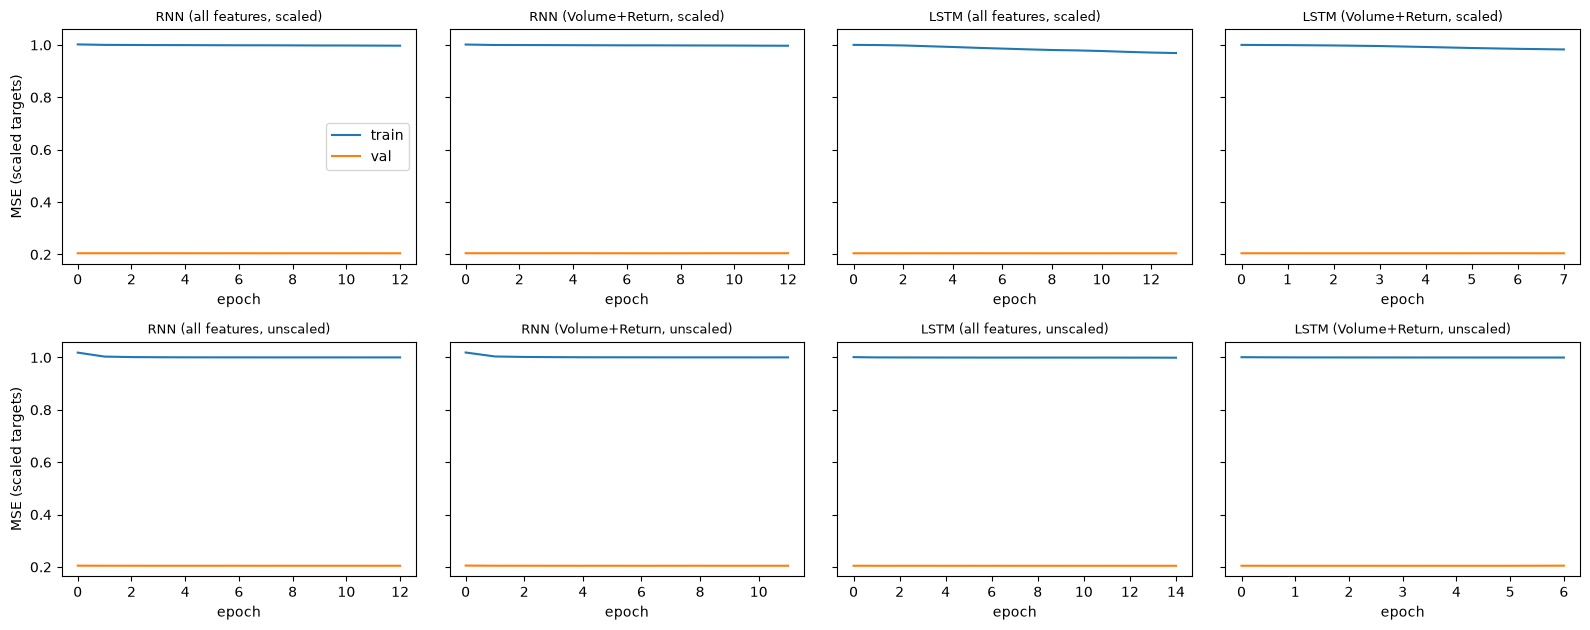

In [11]:
ncols = 4
nrows = int(np.ceil(len(histories) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), sharey=True, squeeze=False)
for ax, (name, h) in zip(axes.flat, histories.items()):
    ax.plot(h['train'], label='train')
    ax.plot(h['val'], label='val')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('epoch')
for ax in axes[:, 0]:
    ax.set_ylabel('MSE (scaled targets)')
axes[0, 0].legend()
plt.tight_layout()
plt.show()

### Error by forecast horizon

MAE for each of the 24 predicted hours. If the models only pick up short-term signal, the gap to the baseline should appear in the first hours and vanish afterwards.

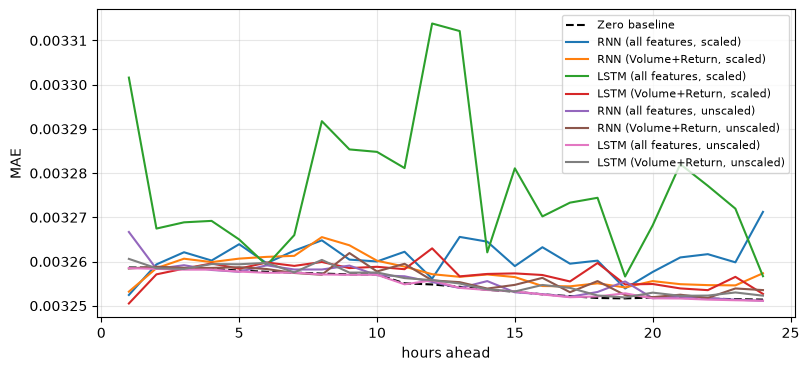

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, TARGET_HOURS + 1), np.abs(y_test).mean(0), 'k--', label='Zero baseline')
for name, pred in test_preds.items():
    plt.plot(np.arange(1, TARGET_HOURS + 1), np.abs(y_test - pred).mean(0), label=name)
plt.xlabel('hours ahead')
plt.ylabel('MAE')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

### Example prediction

Real vs predicted hourly returns for one test day.

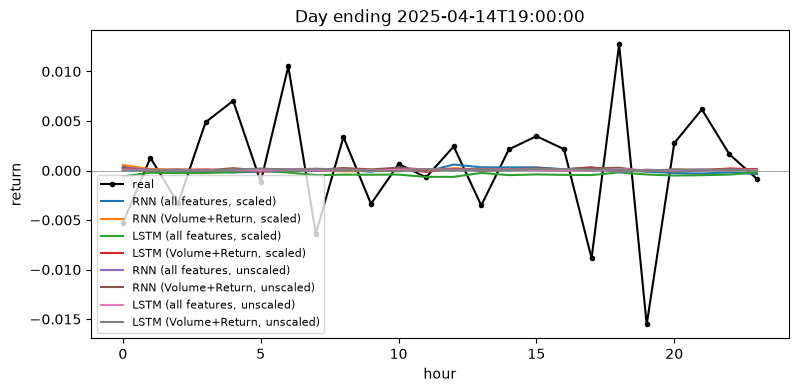

In [13]:
i = len(y_test) // 2
plt.figure(figsize=(9, 4))
plt.plot(y_test[i], 'k-o', ms=3, label='real')
for name, pred in test_preds.items():
    plt.plot(pred[i], label=name)
plt.axhline(0, color='grey', lw=0.5)
plt.title(f"Day ending {dates_test[i]}")
plt.xlabel('hour')
plt.ylabel('return')
plt.legend(fontsize=8)
plt.show()

## Other loss functions

All the models above minimise MSE. On noisy returns, MSE is dominated by the few huge hourly moves, and the safest way to lower it is to predict values close to the mean. We try two alternatives:

- **MAE (L1 loss)**: absolute error. The optimal prediction is the median instead of the mean, and big outliers weigh much less.
- **Direction loss**: we only care whether each hour goes up or down. The model's 24 outputs are treated as logits of "the price goes up this hour", trained with binary cross-entropy. Hours with exactly 0 return are left out of the loss. Since the outputs are no longer returns, only `DirAcc` is meaningful for these models (MSE/MAE are left empty).

These runs use the scaled inputs and all features (change `LOSS_FEATURES` / `LOSS_DATA` to try others). The bar for `DirAcc` is the train-mean baseline (~50.7%).

In [14]:
class DirectionLoss(nn.Module):
    """Binary cross-entropy on the sign of each hourly return; the model outputs a logit for 'up'."""
    def forward(self, pred, target):
        nonzero = target != 0
        return nn.functional.binary_cross_entropy_with_logits(pred[nonzero], (target[nonzero] > 0).float())


LOSS_FEATURES = ALL_FEATURES
LOSS_DATA = 'scaled'
LOSSES = {'MAE': nn.L1Loss, 'Direction': DirectionLoss}

loss_histories, loss_preds = {}, {}
for loss_name, loss_cls in LOSSES.items():
    for cell in ['rnn', 'lstm']:
        name = f"{cell.upper()} ({loss_name} loss)"
        print(f"\n=== {name} ===")
        model, history = train_model(cell, LOSS_FEATURES, data=LOSS_DATA, loss_fn=loss_cls())
        models[name], loss_histories[name] = model, history
        loss_preds[name] = predict(model, to_tensor(select(DATA[LOSS_DATA][2], LOSS_FEATURES)))
        results[name] = evaluate(y_test, loss_preds[name])
        if loss_name == 'Direction':
            # outputs are logits, not returns: only the sign is meaningful
            results[name]['MSE'] = results[name]['MAE'] = np.nan


=== RNN (MAE loss) ===
[rnn] epoch  1  train 0.5119  val 0.2591  (0.9s)
[rnn] epoch  2  train 0.5102  val 0.2591  (0.9s)
[rnn] epoch  3  train 0.5100  val 0.2591  (0.9s)
[rnn] epoch  4  train 0.5099  val 0.2591  (0.8s)
[rnn] epoch  5  train 0.5098  val 0.2591  (0.8s)
[rnn] epoch  6  train 0.5098  val 0.2591  (0.8s)
[rnn] epoch  7  train 0.5098  val 0.2591  (0.8s)
[rnn] epoch  8  train 0.5098  val 0.2591  (0.9s)
[rnn] epoch  9  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 10  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 11  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 12  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 13  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 14  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 15  train 0.5097  val 0.2591  (0.9s)
[rnn] epoch 16  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 17  train 0.5097  val 0.2591  (0.9s)
[rnn] epoch 18  train 0.5097  val 0.2591  (0.8s)
[rnn] epoch 19  train 0.5097  val 0.2591  (0.9s)
[rnn] epoch 20  train 0.5097  val 0.2591  (0.

In [15]:
results_df = pd.DataFrame(results).T
results_df['MSE vs zero'] = results_df['MSE'] / results_df.loc['Zero baseline', 'MSE']
results_df.style.format({'MSE': '{:.3e}', 'MAE': '{:.3e}', 'DirAcc': '{:.2%}', 'MSE vs zero': '{:.3f}'}, na_rep='–')

,MSE,MAE,DirAcc,MSE vs zero
Zero baseline,2.514e-05,3.255e-03,–,1.000
Train-mean baseline,2.515e-05,3.256e-03,50.67%,1.000
"RNN (all features, scaled)",2.518e-05,3.261e-03,50.21%,1.001
"RNN (Volume+Return, scaled)",2.516e-05,3.258e-03,50.15%,1.001
"LSTM (all features, scaled)",2.528e-05,3.277e-03,49.64%,1.005
"LSTM (Volume+Return, scaled)",2.516e-05,3.257e-03,50.11%,1.001
"RNN (all features, unscaled)",2.515e-05,3.256e-03,50.45%,1.000
"RNN (Volume+Return, unscaled)",2.515e-05,3.256e-03,50.39%,1.000
"LSTM (all features, unscaled)",2.514e-05,3.255e-03,50.61%,1.000
"LSTM (Volume+Return, unscaled)",2.514e-05,3.256e-03,50.34%,1.000


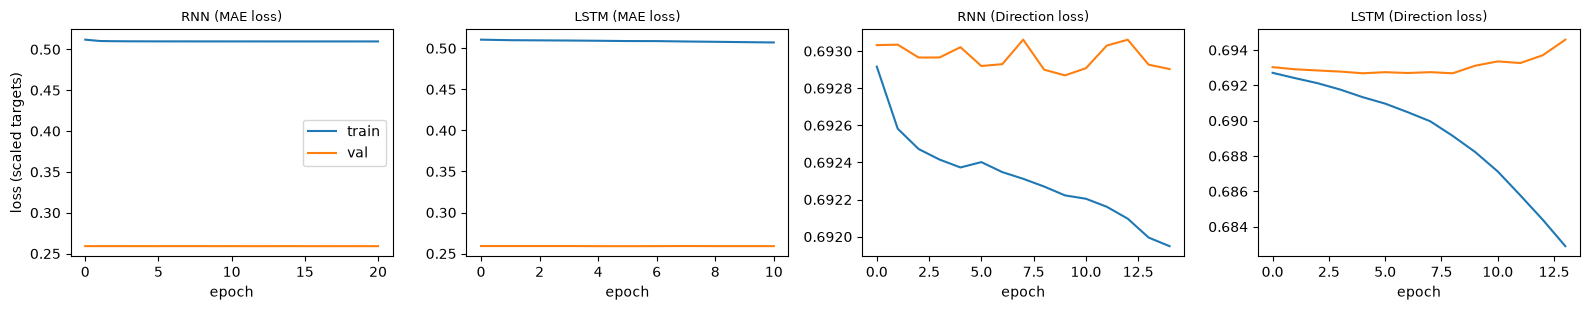

In [16]:
fig, axes = plt.subplots(1, len(loss_histories), figsize=(4 * len(loss_histories), 3.2))
for ax, (name, h) in zip(axes, loss_histories.items()):
    ax.plot(h['train'], label='train')
    ax.plot(h['val'], label='val')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('epoch')
axes[0].set_ylabel('loss (scaled targets)')
axes[0].legend()
plt.tight_layout()
plt.show()

## Gradient boosting

Tree ensembles split on the *order* of the feature values, so they don't care how the inputs are scaled, and they don't need tiny values or huge prices to be squeezed into a nice range the way the RNN/LSTM do. We use scikit-learn's `HistGradientBoostingRegressor` (a LightGBM-style implementation).

Trees can't extrapolate either: any test price above the training maximum lands in the same leaf. So instead of the raw 168 x 6 window we build stationary, tabular features from the unscaled data:

- the last `LAGS` hourly returns
- the last `LAGS` hourly ranges `(High - Low) / Close`
- the last `LAGS` hourly volumes, as log volume relative to the week's mean log volume
- window summaries: cumulative return and return volatility over the last 24h and 168h, mean range over 24h and 168h, distance of the last close to the week's high and low
- the hour of day of the first predicted hour (volatility has a daily pattern)

One model is trained per forecast hour (24 models per loss), with early stopping on the same time-ordered validation set as the networks. As with the networks, the targets are divided by `y_scale` for fitting: the early-stopping tolerance is absolute (`1e-7`), and MSE on raw returns (~1e-4) would make every improvement look like zero.

In [17]:
from sklearn.ensemble import HistGradientBoostingRegressor

LAGS = 24
iO, iH, iL, iC, iV, iR = (feature_cols.index(c) for c in ['Open', 'High', 'Low', 'Close', 'Volume', 'Return'])

def make_tabular(X_raw, dates):
    ret, close = X_raw[:, :, iR], X_raw[:, :, iC]
    rng = (X_raw[:, :, iH] - X_raw[:, :, iL]) / close
    logvol = np.log1p(X_raw[:, :, iV])
    rel_vol = logvol - logvol.mean(1, keepdims=True)
    first_target_hour = (pd.DatetimeIndex(dates) - pd.Timedelta(hours=TARGET_HOURS - 1)).hour.values

    lag_blocks = [ret[:, -LAGS:][:, ::-1], rng[:, -LAGS:][:, ::-1], rel_vol[:, -LAGS:][:, ::-1]]
    summary = {
        'ret_sum_24': ret[:, -24:].sum(1),
        'ret_sum_168': ret.sum(1),
        'ret_std_24': ret[:, -24:].std(1),
        'ret_std_168': ret.std(1),
        'range_mean_24': rng[:, -24:].mean(1),
        'range_mean_168': rng.mean(1),
        'close_vs_high_168': close[:, -1] / X_raw[:, :, iH].max(1) - 1,
        'close_vs_low_168': close[:, -1] / X_raw[:, :, iL].min(1) - 1,
        'hour': first_target_hour,
    }
    names = ([f'ret_lag{k}' for k in range(1, LAGS + 1)] + [f'range_lag{k}' for k in range(1, LAGS + 1)]
             + [f'relvol_lag{k}' for k in range(1, LAGS + 1)] + list(summary))
    X_tab = np.column_stack(lag_blocks + list(summary.values())).astype(np.float32)
    return pd.DataFrame(X_tab, columns=names)

n_val = len(X_val_raw)
dates_tr, dates_va = dates_train[:len(X_train_raw)], dates_train[-n_val:]
T_train = make_tabular(X_train_raw, dates_tr)
T_val = make_tabular(X_val_raw, dates_va)
T_test = make_tabular(X_test_raw, dates_test)
print('Tabular features:', T_train.shape, T_val.shape, T_test.shape)
T_train.describe().T.head(10)

Tabular features: (92830, 81) (10335, 81) (25839, 81)


,count,mean,std,min,25%,50%,75%,max
ret_lag1,92830.0,0.000146,0.010780,-0.293396,-0.002722,-1.455192e-11,0.003076,0.348236
ret_lag2,92830.0,0.000146,0.010780,-0.293396,-0.002722,-1.455192e-11,0.003076,0.348236
ret_lag3,92830.0,0.000146,0.010779,-0.293396,-0.002722,-1.455192e-11,0.003076,0.348236
ret_lag4,92830.0,0.000146,0.010779,-0.293396,-0.002722,-1.455192e-11,0.003076,0.348236
ret_lag5,92830.0,0.000146,0.010779,-0.293396,-0.002721,-1.455192e-11,0.003076,0.348236
ret_lag6,92830.0,0.000146,0.010779,-0.293396,-0.002721,-1.455192e-11,0.003076,0.348236
ret_lag7,92830.0,0.000148,0.010788,-0.293396,-0.002721,-1.455192e-11,0.003076,0.348236
ret_lag8,92830.0,0.000148,0.010788,-0.293396,-0.002721,-1.455192e-11,0.003076,0.348236
ret_lag9,92830.0,0.000148,0.010788,-0.293396,-0.002721,-1.455192e-11,0.003076,0.348236
ret_lag10,92830.0,0.000148,0.010788,-0.293396,-0.002721,-1.455192e-11,0.003076,0.348236


In [18]:
GB_PARAMS = dict(learning_rate=0.05, max_iter=500, max_leaf_nodes=31, min_samples_leaf=200,
                 l2_regularization=1.0, early_stopping=True, n_iter_no_change=20, random_state=SEED)
GB_LOSSES = {'MSE': 'squared_error', 'MAE': 'absolute_error'}

gb_models, gb_preds = {}, {}
for loss_name, loss in GB_LOSSES.items():
    name = f"GB ({loss_name} loss)"
    t0 = time.time()
    gb_models[name] = []
    pred = np.zeros_like(y_test)
    for h in range(TARGET_HOURS):
        gb = HistGradientBoostingRegressor(loss=loss, **GB_PARAMS)
        gb.fit(T_train, y_train[:, h] / y_scale, X_val=T_val, y_val=y_val[:, h] / y_scale)
        gb_models[name].append(gb)
        pred[:, h] = gb.predict(T_test) * y_scale
    gb_preds[name] = pred
    results[name] = evaluate(y_test, pred)
    n_iters = [m.n_iter_ for m in gb_models[name]]
    print(f"{name}: {time.time() - t0:.0f}s, boosting iterations per hour: min {min(n_iters)}, max {max(n_iters)}")

GB (MSE loss): 15s, boosting iterations per hour: min 21, max 76
GB (MAE loss): 18s, boosting iterations per hour: min 25, max 171


If the number of boosting iterations stays very low (close to `n_iter_no_change`), the validation loss stopped improving almost immediately, i.e. the trees found little that generalises.

In [19]:
results_df = pd.DataFrame(results).T
results_df['MSE vs zero'] = results_df['MSE'] / results_df.loc['Zero baseline', 'MSE']
results_df.style.format({'MSE': '{:.3e}', 'MAE': '{:.3e}', 'DirAcc': '{:.2%}', 'MSE vs zero': '{:.3f}'}, na_rep='–')

,MSE,MAE,DirAcc,MSE vs zero
Zero baseline,2.514e-05,3.255e-03,–,1.000
Train-mean baseline,2.515e-05,3.256e-03,50.67%,1.000
"RNN (all features, scaled)",2.518e-05,3.261e-03,50.21%,1.001
"RNN (Volume+Return, scaled)",2.516e-05,3.258e-03,50.15%,1.001
"LSTM (all features, scaled)",2.528e-05,3.277e-03,49.64%,1.005
"LSTM (Volume+Return, scaled)",2.516e-05,3.257e-03,50.11%,1.001
"RNN (all features, unscaled)",2.515e-05,3.256e-03,50.45%,1.000
"RNN (Volume+Return, unscaled)",2.515e-05,3.256e-03,50.39%,1.000
"LSTM (all features, unscaled)",2.514e-05,3.255e-03,50.61%,1.000
"LSTM (Volume+Return, unscaled)",2.514e-05,3.256e-03,50.34%,1.000


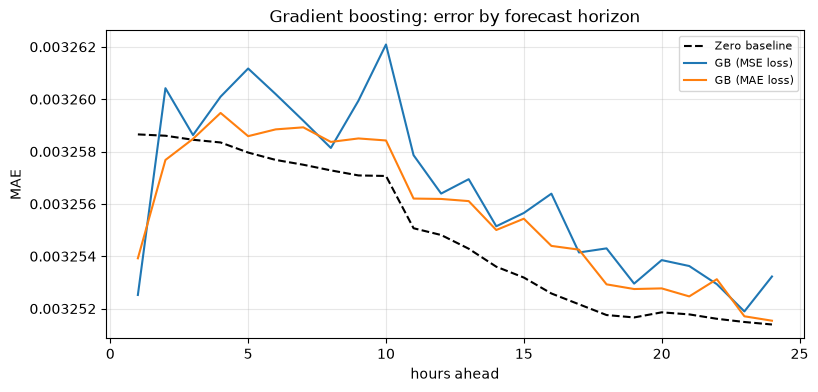

In [20]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, TARGET_HOURS + 1), np.abs(y_test).mean(0), 'k--', label='Zero baseline')
for name, pred in gb_preds.items():
    plt.plot(np.arange(1, TARGET_HOURS + 1), np.abs(y_test - pred).mean(0), label=name)
plt.xlabel('hours ahead')
plt.ylabel('MAE')
plt.title('Gradient boosting: error by forecast horizon')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

### Which features matter?

Permutation importance for the 1-hour-ahead MSE model on the test set: how much the test MSE grows when one feature is shuffled. Values near zero (or negative) mean the model doesn't actually rely on that feature.

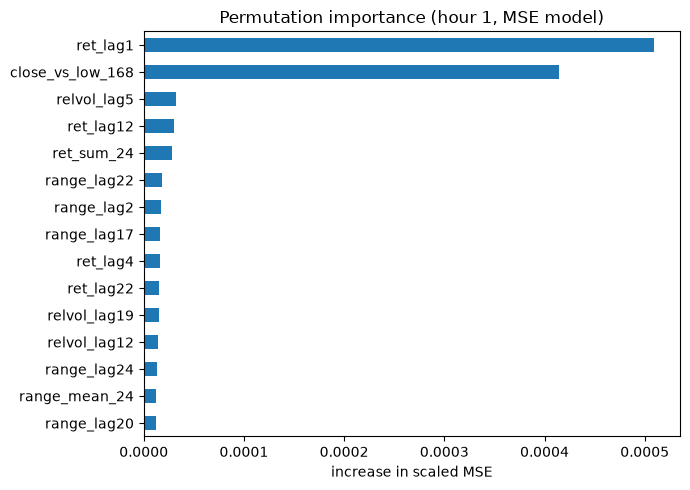

In [21]:
from sklearn.inspection import permutation_importance

gb_h1 = gb_models['GB (MSE loss)'][0]
imp = permutation_importance(gb_h1, T_test, y_test[:, 0] / y_scale, scoring='neg_mean_squared_error',
                             n_repeats=5, random_state=SEED)
importance = pd.Series(imp.importances_mean, index=T_test.columns).sort_values()
importance.tail(15).plot.barh(figsize=(7, 5), title='Permutation importance (hour 1, MSE model)')
plt.xlabel('increase in scaled MSE')
plt.tight_layout()
plt.show()